In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold,train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn import tree
from sklearn.tree import plot_tree, export_text
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

plt.rcParams['lines.linewidth'] = 3
plt.rcParams['figure.figsize'] = [8, 5]
plt.rcParams['font.size'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
# plt.rcParams.keys()
from matplotlib import colors
from sklearn.linear_model import RidgeClassifier
from pygam import LogisticGAM, s, f
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use('ggplot')

In [2]:
df = pd.read_csv('../../datasets/group_14.csv')
df["focus_factor"] = (
    df["focus_factor"]
    .astype(str)                  # ensure it's string
    .str.replace(",", ".", regex=False)  # replace comma with dot
)
df["focus_factor"] = pd.to_numeric(df["focus_factor"], errors="coerce").astype(float)

In [3]:
# Split dataset
data_set = df.copy()
y = data_set['target_class']
X = data_set.drop(columns=["target_class"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Decision Tree

## Create Classification Tree

In [4]:
# Basic Decision Tree (no tuning)
dt = DecisionTreeClassifier(random_state=42)  # default hyperparameters
dt.fit(X_train, y_train)

# Evaluate
train_acc = dt.score(X_train, y_train)
test_acc = dt.score(X_test, y_test)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

Train accuracy: 1.0
Test accuracy: 0.7416666666666667



+ The train accuracy is 100%, which means the Decision Tree perfectly memorized the training data.
+ The test accuracy is 74.2%, which is noticeably lower than the training accuracy.

This large gap indicates overfitting: the tree is too complex and captures noise in the training set rather than general patterns.

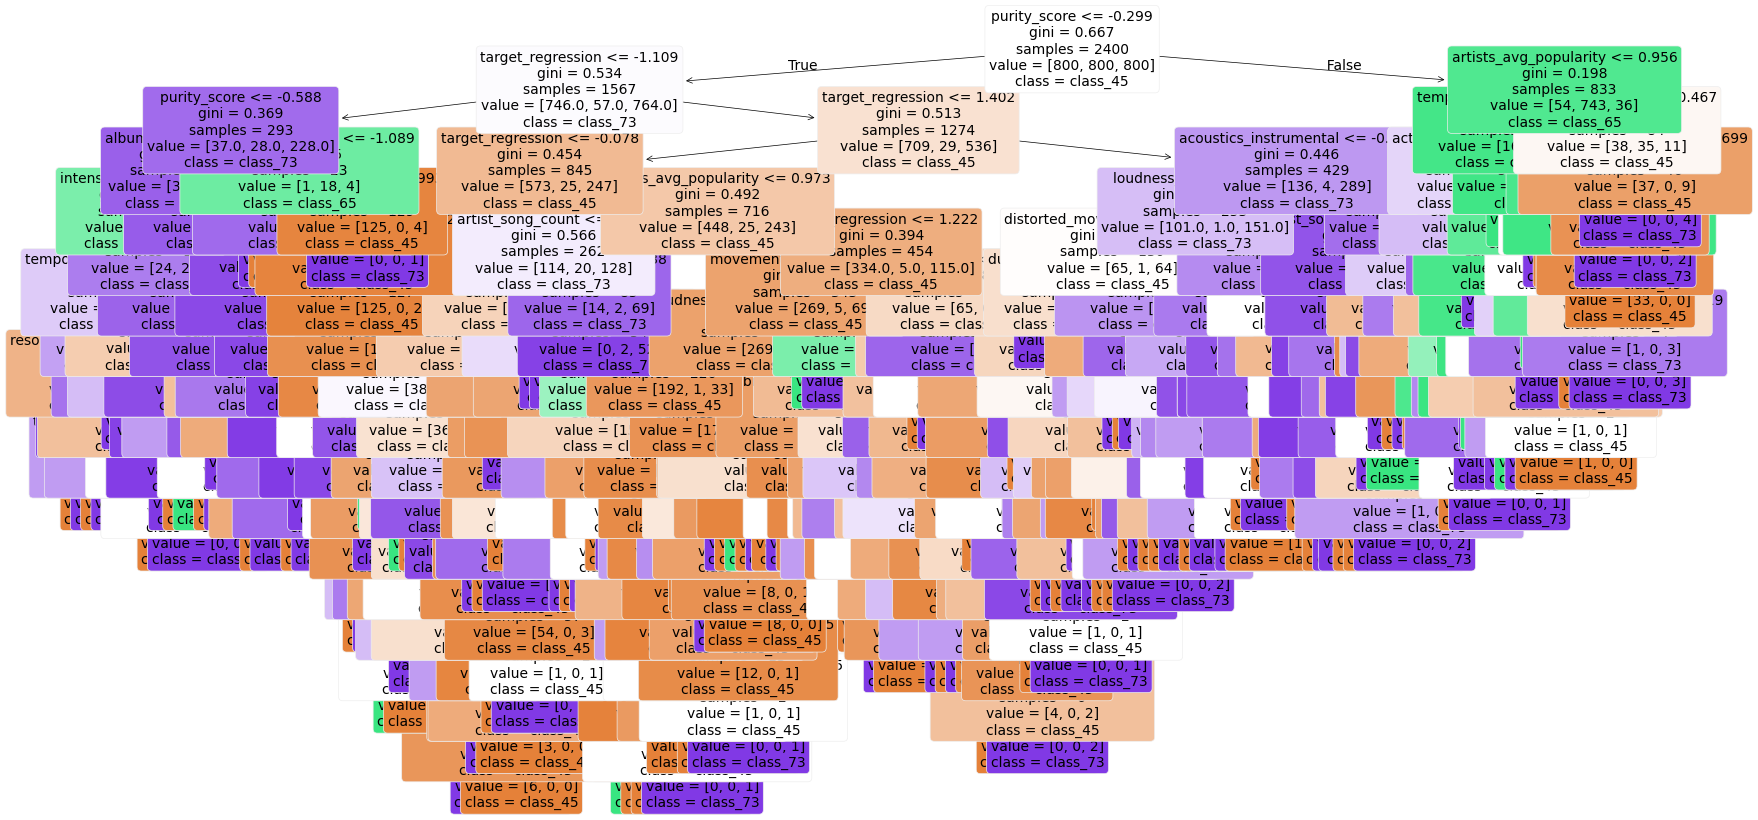

In [5]:
# Draws the Decision Tree
plt.figure(figsize=(20,10))
plot_tree(
    dt, 
    feature_names=X.columns, 
    class_names=[str(c) for c in y.unique()],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

+ The tree is very deep, which explains why the train accuracy is 100% but the test accuracy is lower (74.2%) — the tree has memorized the training data (overfitting).

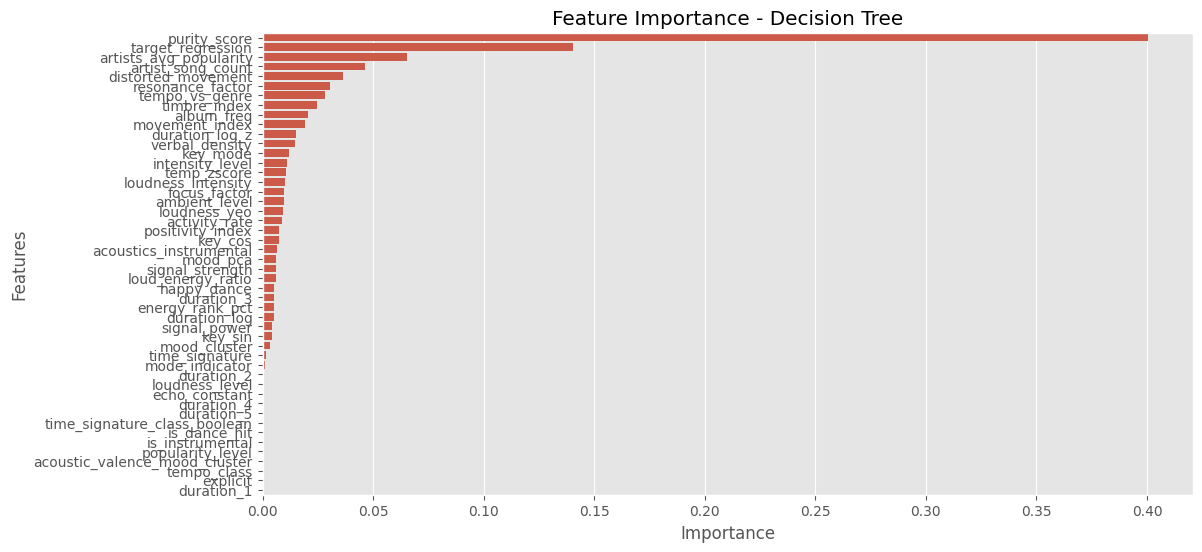

In [6]:

feature_importance = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

### Top features:

+ purity_score → 0.40 (most important)

+ target_regression → 0.14

+ artists_avg_popularity → 0.065

+ artist_song_count → 0.046

+ distorted_movement → 0.037

Many features have 0 importance, meaning they were never used for splitting.
The tree relies mainly on a small subset of predictive features, while the rest contribute little to classification.

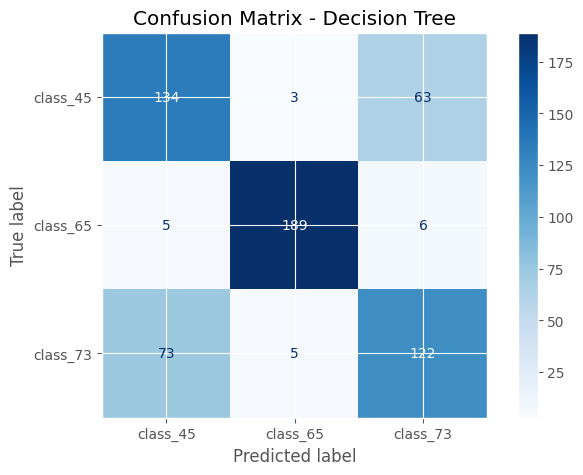

Classification Report:
               precision    recall  f1-score   support

    class_45       0.63      0.67      0.65       200
    class_65       0.96      0.94      0.95       200
    class_73       0.64      0.61      0.62       200

    accuracy                           0.74       600
   macro avg       0.74      0.74      0.74       600
weighted avg       0.74      0.74      0.74       600



In [7]:
# Predict on test set
y_pred = dt.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=dt.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Decision Tree")
plt.show()

# Classification report
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

+ The tree is overfitting, capturing training data perfectly but generalizing less well to unseen data.

+ class_65 is predicted very well, while class_45 and class_73 are harder to classify due to overlapping feature patterns.

To improve, hyperparameter tuning (max depth, min samples per leaf, etc.) is needed to reduce overfitting.

## Decision Tree Classifier Hyperparameter tuning



In [8]:
# Parameters selected for tuning
params = {
    'max_depth': [2, 3, 5, 10, 20],            # limits tree depth; small values reduce overfitting, large values allow complex splits
    'min_samples_leaf': [5, 10, 20, 50, 100],  # minimum samples per leaf; larger values simplify tree and improve generalization
    'criterion': ["gini", "entropy"],          # measures impurity; testing both helps choose best for our dataset
    'splitter':("best", "random")              # "best" selects optimal split, "random" adds variability to reduce overfitting
}

# Build GridSearchCV
tree_cv = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
    cv=5  # 5-fold cross-validation ensures robust performance evaluation
)

In [9]:
#Fit tree
tree_cv.fit(X_train, y_train)
best_params = tree_cv.best_params_
best_score = tree_cv.best_score_
best_dt = tree_cv.best_estimator_

#Print results
print(f"Best paramters: {best_params})")
print(f"Best CV score : {best_score})")
print(f"Best Estimator : {best_dt})")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best paramters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5, 'splitter': 'best'})
Best CV score : 0.7825)
Best Estimator : DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=5,
                       random_state=42))


Limiting depth and leaf size reduced overfitting compared to the basic tree.
The model now generalizes better, balancing training performance and test accuracy.

The tuned tree is simpler, avoids memorizing noise, and focuses on the most predictive features.

In [10]:
# Accuracy
train_acc = best_dt.score(X_train, y_train)
test_acc = best_dt.score(X_test, y_test)
print("Train accuracy after tuning:", train_acc)
print("Test accuracy after tuning:", test_acc)

Train accuracy after tuning: 0.7866666666666666
Test accuracy after tuning: 0.7816666666666666


+ The train and test accuracies are very close, indicating the model no longer overfits the training data.

+ Limiting max_depth and min_samples_leaf helped the tree generalize better.

Overall, the tuned Decision Tree achieves a balanced performance, capturing the main patterns in the data without memorizing noise.

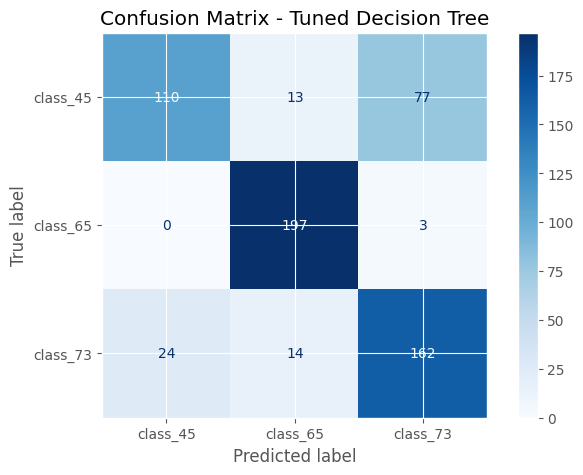

Classification Report:
               precision    recall  f1-score   support

    class_45       0.82      0.55      0.66       200
    class_65       0.88      0.98      0.93       200
    class_73       0.67      0.81      0.73       200

    accuracy                           0.78       600
   macro avg       0.79      0.78      0.77       600
weighted avg       0.79      0.78      0.77       600



In [11]:
y_pred = best_dt.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=best_dt.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_dt.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Tuned Decision Tree")
plt.show()

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

+ class_45: The model predicts this class fairly precisely, but misses many true class_45 instances.

+ class_65: Excellent performance; the model rarely misclassifies this class.

+ class_73: Decent performance, but some false positives lower precision.

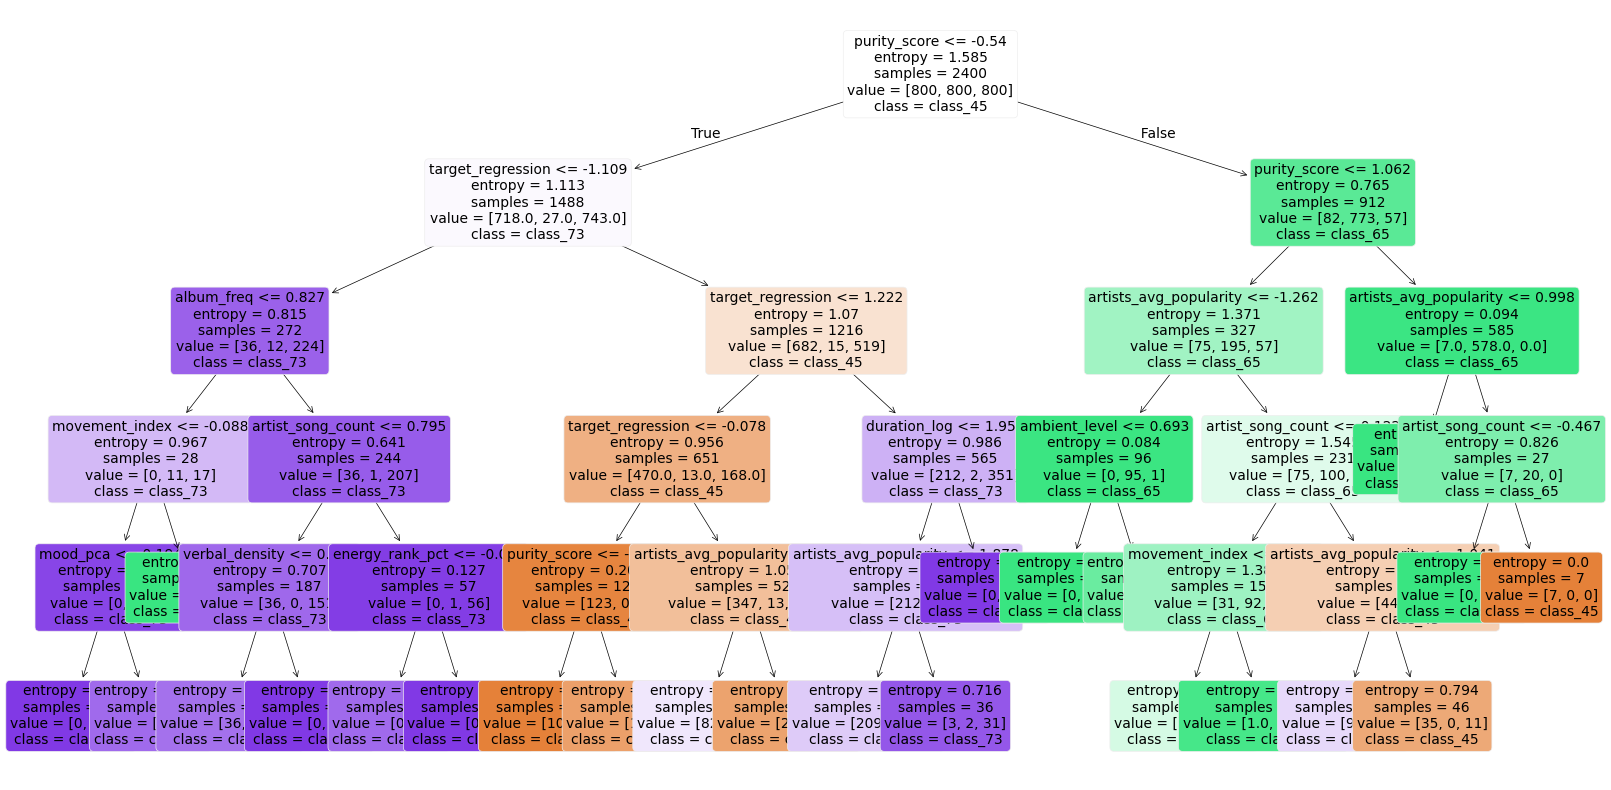

In [12]:
#Draw Tree
plt.figure(figsize=(20,10))
plot_tree(
    best_dt, 
    feature_names=X.columns, 
    class_names=[str(c) for c in y.unique()],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()


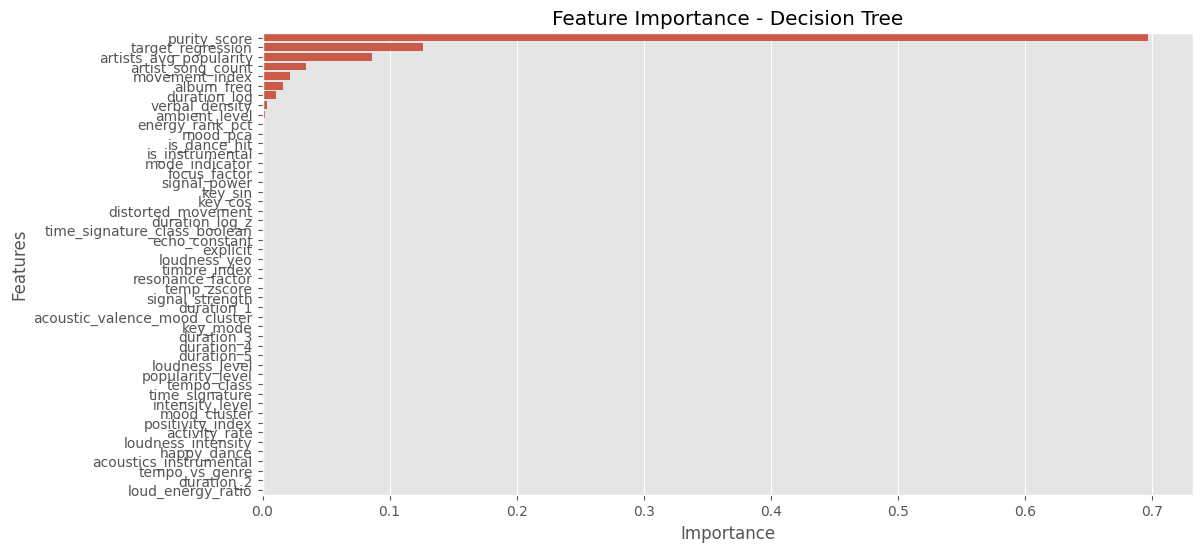

In [13]:
#Draw feature importace grath
feature_importance_best = pd.Series(best_dt.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=feature_importance_best.values, y=feature_importance_best.index)
plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()



### **Feature Importance Comparison: Before vs After Tuning**

| Feature                | Before Tuning | After Tuning | Comment                                                   |
| ---------------------- | ------------- | ------------ | --------------------------------------------------------- |
| purity_score           | 0.401         | 0.697        | Most important in both; importance increased after tuning |
| target_regression      | 0.141         | 0.126        | Still highly influential                                  |
| artists_avg_popularity | 0.065         | 0.086        | Slight increase in importance after tuning                |
| artist_song_count      | 0.046         | 0.034        | Minor change                                              |
| distorted_movement     | 0.037         | 0.000        | Used more before tuning, ignored after tuning             |
| resonance_factor       | 0.031         | 0.000        | Important before tuning, ignored after tuning             |
| tempo_vs_genre         | 0.028         | 0.000        | Dropped after tuning                                      |
| timbre_index           | 0.025         | 0.000        | Dropped after tuning                                      |
| album_freq             | 0.020         | 0.016        | Small decrease                                            |
| movement_index         | 0.019         | 0.022        | Slight increase                                           |
| Other features         | 0.000–0.015   | 0.000–0.001  | Many features ignored after tuning                        |
---

* **Top features remain mostly consistent**, with `purity_score` and `target_regression` driving the main predictive power.
* After tuning, the tree **focuses more on key predictive features** and ignores some features that were previously used, which helps **reduce overfitting**.
* Tuning led to a **simpler and more generalizable tree**, balancing accuracy across classes while relying on a smaller, more meaningful set of features.

# Random Forest

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [15]:
from sklearn.ensemble import RandomForestClassifier
# Baseline RF
rf = RandomForestClassifier(random_state=42, n_jobs=-1)  # default params, reasonable baseline
rf.fit(X_train, y_train)

# Scores
train_acc_rf = rf.score(X_train, y_train)
test_acc_rf = rf.score(X_test, y_test)
print("RF train acc:", train_acc_rf)
print("RF test acc:", test_acc_rf)

# Predictions and basic report
y_pred_rf = rf.predict(X_test)
print("Classification Report (RF baseline):\n", classification_report(y_test, y_pred_rf))

RF train acc: 1.0
RF test acc: 0.775
Classification Report (RF baseline):
               precision    recall  f1-score   support

    class_45       0.67      0.69      0.67       200
    class_65       0.95      0.98      0.96       200
    class_73       0.71      0.66      0.68       200

    accuracy                           0.78       600
   macro avg       0.77      0.78      0.77       600
weighted avg       0.77      0.78      0.77       600



The model performs well overall (77–78% accuracy) but:
 + Class 65 dominates performance (very high precision/recall).
 + Class 45 and 73 are harder to classify, especially class 73 (lower recall).

Overfitting is clearly present because:
+ Train accuracy = 100%
+ Test accuracy = 77.5%

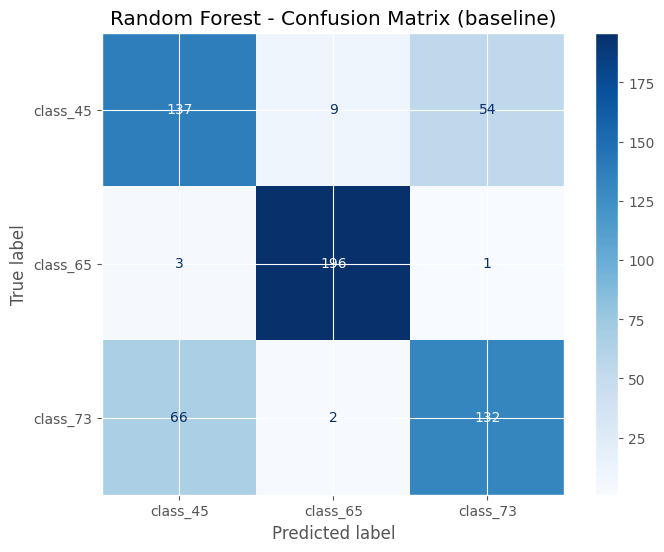

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
fig, ax = plt.subplots(figsize=(8,6))
disp.plot(ax=ax, cmap=plt.cm.Blues)
plt.title("Random Forest - Confusion Matrix (baseline)")
plt.show()

RF feature importances (baseline):

purity_score                     0.116959
signal_strength                  0.081056
loud_energy_ratio                0.067846
target_regression                0.067027
artists_avg_popularity           0.064767
signal_power                     0.046613
energy_rank_pct                  0.037836
album_freq                       0.034799
intensity_level                  0.028317
duration_log                     0.027813
duration_log_z                   0.025497
resonance_factor                 0.024789
tempo_vs_genre                   0.023503
timbre_index                     0.023462
loudness_yeo                     0.023292
distorted_movement               0.022700
artist_song_count                0.019271
verbal_density                   0.018667
movement_index                   0.017965
mood_pca                         0.017884
acoustics_instrumental           0.017824
happy_dance                      0.016605
positivity_index                 0.01547

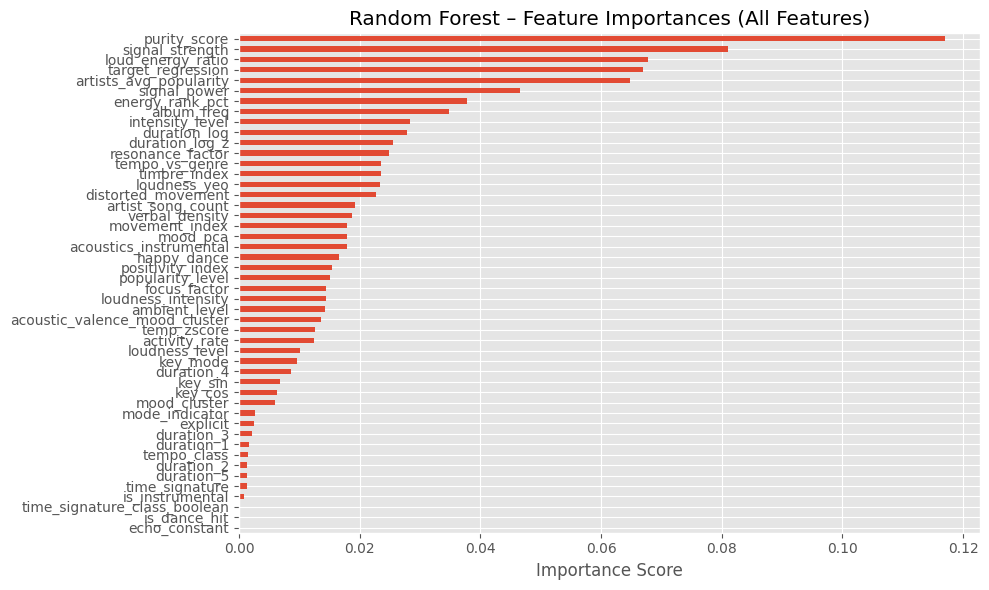

In [36]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("RF feature importances (baseline):\n")
print(importances)

# Plot ALL feature importances
plt.figure(figsize=(10, 6))   # taller figure to fit all bars
importances.plot(kind='barh')
plt.gca().invert_yaxis()        # most important at the top
plt.title("Random Forest – Feature Importances (All Features)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

+ purity_score is again the strongest predictor → matches your DT results.
+ energy/loudness/signal features are now much more relevant than in the Decision Tree.
+ Some movement/timbre/musicological features also matter.

Many features have very low or zero importance (expected for RF with many correlated variables).
This shows RF captures nonlinear interactions much better than the Decision Tree.

### Hyperparameter tuning for Random Forest

In [ ]:
params_rf = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 0.3],
    'class_weight': [None, 'balanced']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=params_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)


print("Best RF params:", rf_grid.best_params_)
print("Best CV score:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_


# Predictions from tuned RF model
y_pred_best_rf= best_rf.predict(X_test)

# Evaluate best RF
print("Train acc (best RF):", best_rf.score(X_train, y_train))
print("Test acc (best RF):", best_rf.score(X_test, y_test))
print("Classification Report (best RF):\n", classification_report(y_test, y_pred_best_rf))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best RF params: {'class_weight': None, 'max_depth': 20, 'max_features': 0.3, 'min_samples_leaf': 5, 'n_estimators': 300}
Best CV score: 0.8045833333333334
Train acc (best RF): 0.93875
Test acc (best RF): 0.795
Classification Report (best RF):
               precision    recall  f1-score   support

    class_45       0.72      0.70      0.71       200
    class_65       0.92      0.97      0.95       200
    class_73       0.73      0.70      0.72       200

    accuracy                           0.80       600
   macro avg       0.79      0.79      0.79       600
weighted avg       0.79      0.80      0.79       600



+ Train Accuracy: 0.9388
+ Test Accuracy: 0.795

Generalization gap:
≈ 0.9388 − 0.795 ≈ 0.144 (14.4%)

This gap shows some overfitting, but much less than the baseline Random Forest (which had train = 1.0).
The tuned model generalizes better and is more stable.

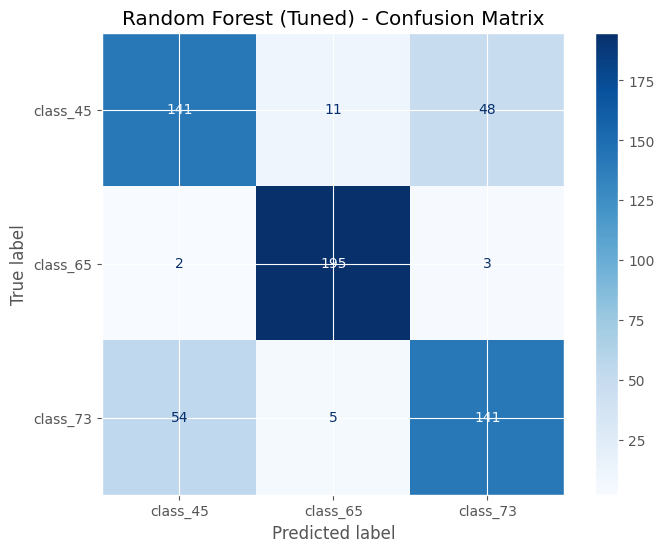

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best_rf, labels=best_rf.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=True)
plt.title("Random Forest (Tuned) - Confusion Matrix")
plt.show()

Random Forest - ALL Feature Importances:
purity_score                     0.193601
target_regression                0.092738
loud_energy_ratio                0.081899
energy_rank_pct                  0.074461
artists_avg_popularity           0.068696
signal_strength                  0.068270
signal_power                     0.052930
album_freq                       0.037903
loudness_yeo                     0.024183
intensity_level                  0.023960
artist_song_count                0.022360
popularity_level                 0.020753
duration_log                     0.018995
duration_log_z                   0.018169
movement_index                   0.017257
verbal_density                   0.015589
acoustics_instrumental           0.014771
resonance_factor                 0.012721
tempo_vs_genre                   0.011673
focus_factor                     0.011216
timbre_index                     0.011200
happy_dance                      0.010935
distorted_movement               0.

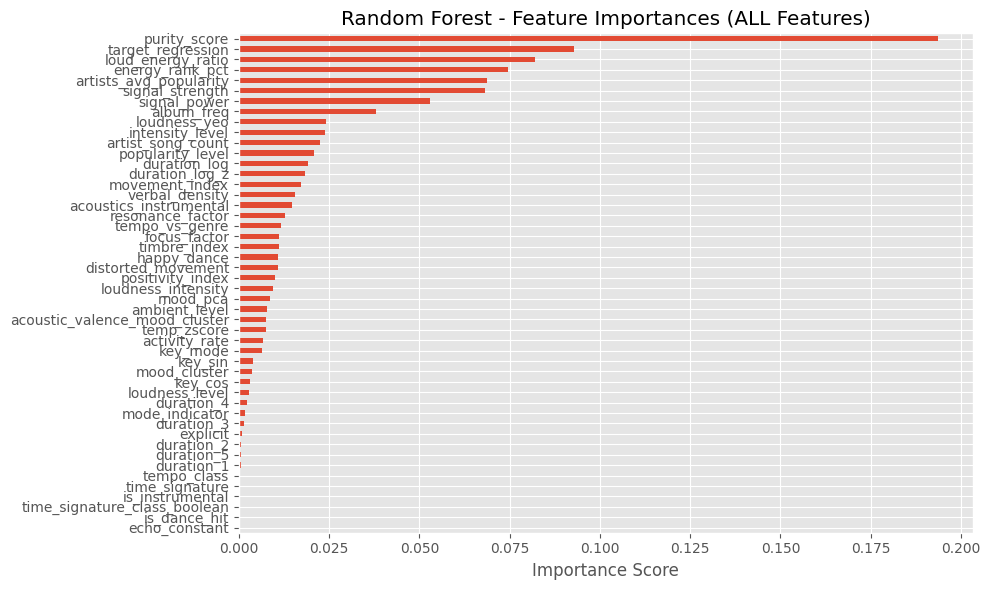

In [ ]:
# Compute all importances
rf_importances = pd.Series(best_rf.feature_importances_, index=X.columns)
rf_importances_sorted = rf_importances.sort_values(ascending=False)

# Print all importances
print("Random Forest - ALL Feature Importances:")
print(rf_importances_sorted)

plt.figure(figsize=(10, 6))
rf_importances_sorted.plot(kind='barh')
plt.gca().invert_yaxis()  # most important at the top
plt.title("Random Forest - Feature Importances (ALL Features)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

Feature importances became more concentrated

+ purity_score increased from 0.116 → 0.1936

+ target_regression increased from 0.067 → 0.0927

This means RF tuned found a more stable splitting pattern.

Some features gained importance

Examples:

+ loud_energy_ratio (from 0.067 → 0.082)

+ energy_rank_pct (from 0.037 → 0.074)

+ signal_power / signal_strength increased

These reflect deeper interactions captured by the tuned RF.

Many previously useless features still remain at zero

(e.g., time_signature, dance_hit, echo_constant)

This is expected: RF filters out noisy predictors.



# Random Forest Before vs After Tuning

The baseline Random Forest achieved **high training accuracy (1.00)** but a significantly lower **test accuracy (0.775)**, indicating clear **overfitting**. After hyperparameter tuning, the overfitting was substantially reduced:

* **Train accuracy dropped** to **0.938**,
* **Test accuracy increased** to **0.795**,
* Cross-validation score also improved (**0.8046**),

showing that the tuned model generalizes better and is more stable across folds.

### **Class-level performance**

Across both models, class **65** consistently shows the highest precision/recall, while **class 45 and 73** remain harder to separate.
After tuning, class 73 improves slightly (f1 from ~0.68 → ~0.72), suggesting that the tuned tree structure allows the model to capture more subtle patterns for this class.

---

### **Random Forest – Feature Importance Analysis**

**Before Tuning:**

* Feature importance was fairly spread out among many predictors.
* Top features included `purity_score` (0.117), `signal_strength` (0.081), `loud_energy_ratio` (0.068), and `target_regression` (0.067).
* Many features had very low or zero importance, indicating the baseline model relied heavily on a subset of predictors but still considered some weaker features.

**After Tuning:**

* The improved RF shifted more importance to the strongest features: `purity_score` (0.194), `target_regression` (0.093), `loud_energy_ratio` (0.082), and `energy_rank_pct` (0.074).
* The distribution is now more focused on the most predictive variables, while weaker features contribute less.

**Interpretation:**

* Hyperparameter tuning allowed the RF to **prioritize the most informative features**, improving generalization.
* This reduced overfitting compared to the baseline, as the model now relies less on weaker predictors and focuses on variables with the strongest signal.
* Overall, tuning increased the clarity of which features drive predictions and slightly improved accuracy (train: 0.939 → test: 0.795).



In [39]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top_features = importances.head(10)  # top 10 for visualization
print(top_features)

purity_score              0.193601
target_regression         0.092738
loud_energy_ratio         0.081899
energy_rank_pct           0.074461
artists_avg_popularity    0.068696
signal_strength           0.068270
signal_power              0.052930
album_freq                0.037903
loudness_yeo              0.024183
intensity_level           0.023960
dtype: float64


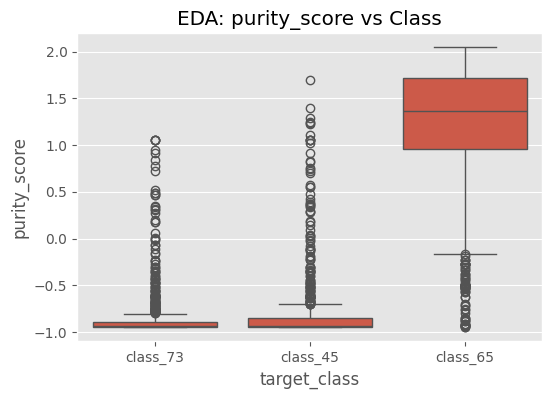

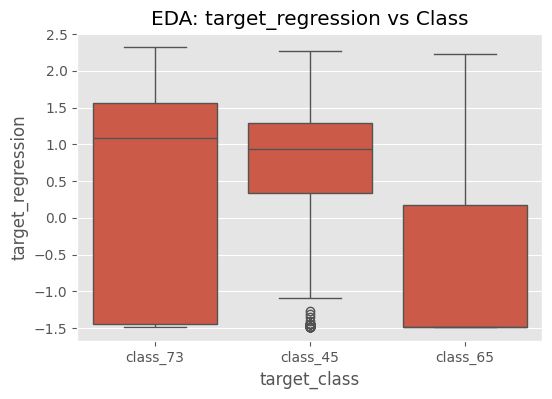

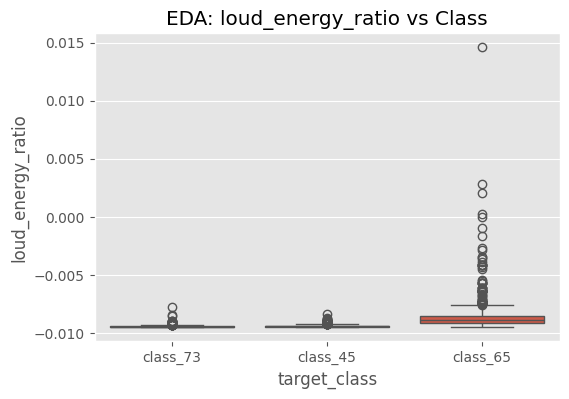

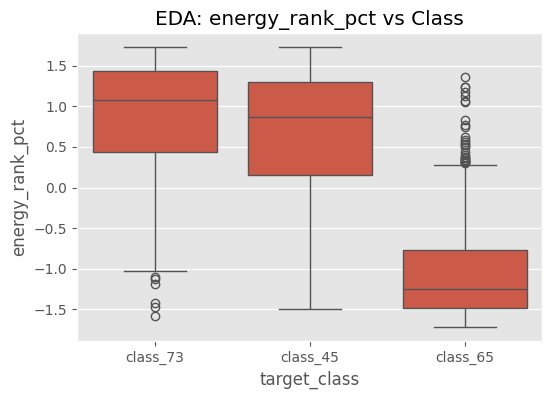

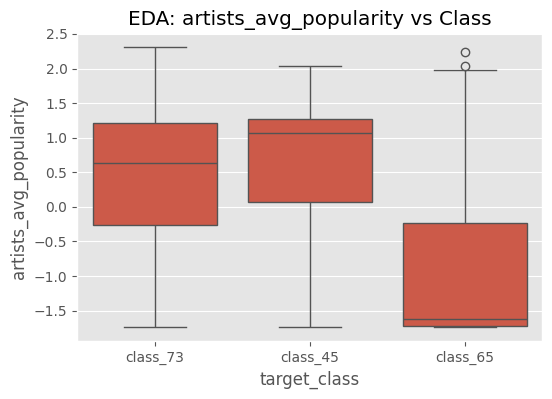

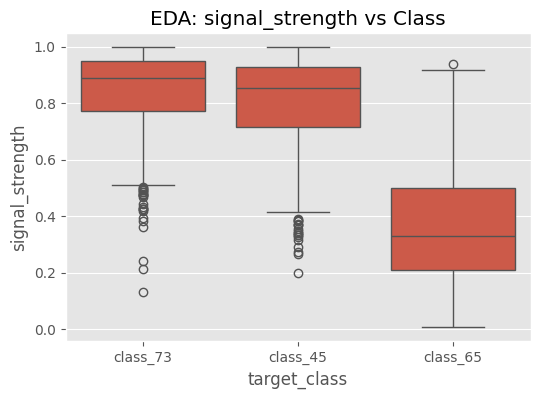

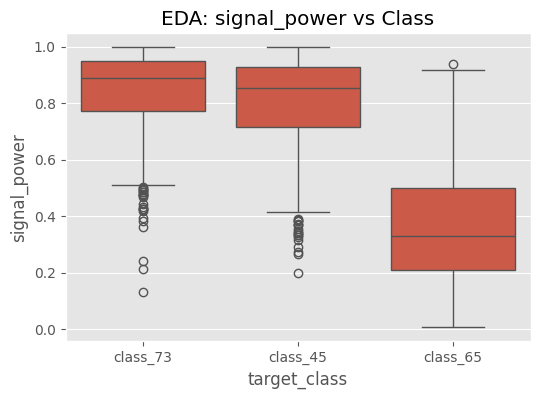

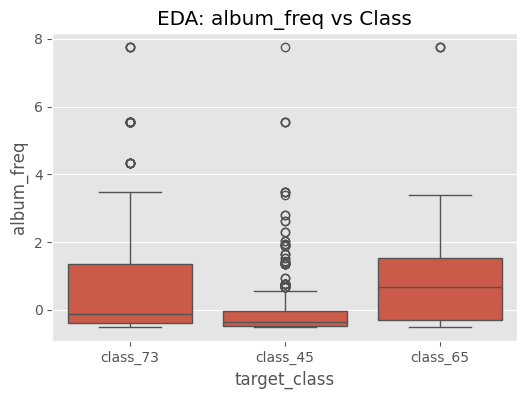

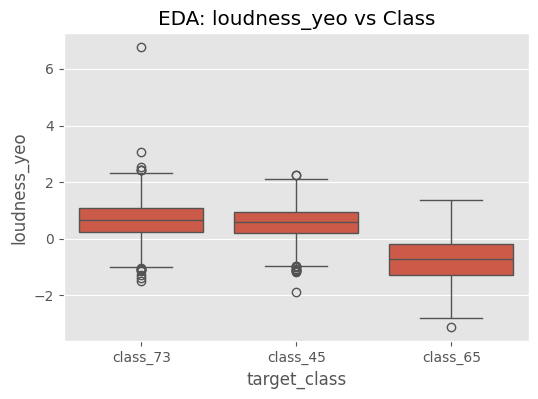

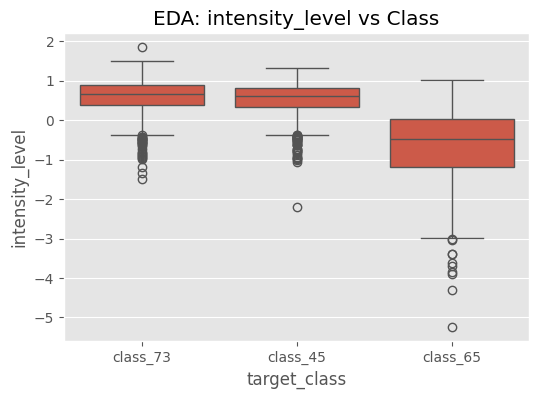

In [40]:
for feature in top_features.index:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=y_train, y=X_train[feature])
    plt.title(f"EDA: {feature} vs Class")
    plt.show()


# Interpretation in Context(TO BE CONTINUES)

Comparing these results with earlier tasks:

### **• Univariate and Bivariate Analysis (Task 2)**

Many of the highly ranked RF features (e.g., **purity_score, loudness/energy features, tempo vs genre, artist popularity-related metrics**) were also among the variables that showed strong separation between classes in EDA.
This reinforces the idea that RF is capturing real signal rather than noise.

### **• Ridge / Lasso (Task 5)**

Features that Lasso retained (strong predictors) overlap heavily with the ones RF now considers important:

* purity_score
* target_regression
* artist popularity metrics
* intensity / energy indicators

This agreement across models increases confidence that these are **structurally important drivers** of class differentiation.